# Methylation compartments vs A/B compartments (Fig 5C–E)

Part of the **[Fig. 5 chapter](fig5.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{compdir}bin_stats.hdf'`  ·  _other_
- `f'{compdir}DifferentialResult/fdr_result/differential.intra_sample_combined.pcQnm.bedGraph'`  ·  _other_
- `f'{pmddir}merged_kmeans4_onehot.hdf'`  ·  _PMD/methyl-compartment_
- `f'{pmddir}{ct}_10kb_hist.h5ad'`  ·  _PMD/methyl-compartment_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm as cm
import matplotlib.patches as patches
from scipy.stats import zscore, pearsonr, norm
from sklearn.cluster import KMeans

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/mC_compartment/'
compdir = f'{indir}analysis/diff_comp/all/'
pmddir = f'{indir}analysis/PMD/10kb/'

In [4]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
res = 100000
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [5]:
binall = pd.read_hdf(f'{compdir}bin_stats.hdf', key='data')
comp = pd.read_csv(f'{compdir}DifferentialResult/fdr_result/differential.intra_sample_combined.pcQnm.bedGraph', sep='\t', header=0, index_col=None)
comp.index = comp['chr'] + '_' + (comp['start'] // res).astype(str)
comp = comp.loc[binall.index, L1_meta.index]


In [6]:
data = pd.read_hdf(f'{pmddir}merged_kmeans4_onehot.hdf', key='data')
data = data.iloc[:, np.arange(L1_meta.shape[0]+1)*4+2]
data[['chr', 'start', 'end']] = data.index.str.split('-').tolist()
data['chrom100k'] = data['chr'] + '_' + (data['start'].astype(int) // res).astype(str)
data = data.drop(['chr', 'start', 'end'], axis=1)
data = data.groupby('chrom100k').mean()
data.columns = data.columns.str.split('-').str[0]


In [7]:
comp = comp.drop(['c10','c16','c14','c31'], axis=1)
data = data.rename({'c35':'c7'}, axis=1)
data = data.loc[comp.index, comp.columns]


In [8]:
def order_row(data, nc):
    data = data.reset_index(drop=True)
    kmeans = KMeans(n_clusters=nc, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(data)
    cluster_df = pd.DataFrame({'Cluster': clusters}, index=data.index)
    merged_data = pd.concat([data, cluster_df], axis=1).groupby(by='Cluster').mean()
    rorder = cg.dendrogram_row.reordered_ind.copy()
    corder = cg.dendrogram_col.reordered_ind.copy()
    leg = merged_data.index[rorder]
    count = pd.Series(clusters).value_counts().loc[leg]
    sorted_data = pd.concat([data[clusters == i] for i in leg], axis=0)
    return (sorted_data, count, cluster_df, corder)

In [9]:
kmeans = KMeans(n_clusters=10, random_state=0, n_init=10)
clusters = kmeans.fit_predict(comp)
cluster_df = pd.DataFrame({'Cluster': clusters}, index=comp.index)
merged_data = pd.concat([comp, cluster_df], axis=1)
sorted_data = merged_data.groupby(by='Cluster').mean()
rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()

In [10]:
nc = 10
group_palette = sns.color_palette('Set3', nc)
tmp, count, label3c, corder = order_row(comp, nc=nc)


In [11]:
comptmp = pd.concat([comp[clusters == i] for i in sorted_data.index[rorder]], axis=0)
datatmp = data.loc[comptmp.index]

In [12]:
comptmp = pd.concat([comp[clusters == i] for i in sorted_data.index[rorder]], axis=0)
datatmp = data.loc[comptmp.index]

In [13]:
nc = 10
group_palette = sns.color_palette('Set3', nc)
tmp, count, label3c, corder = order_row(comp, nc=nc)


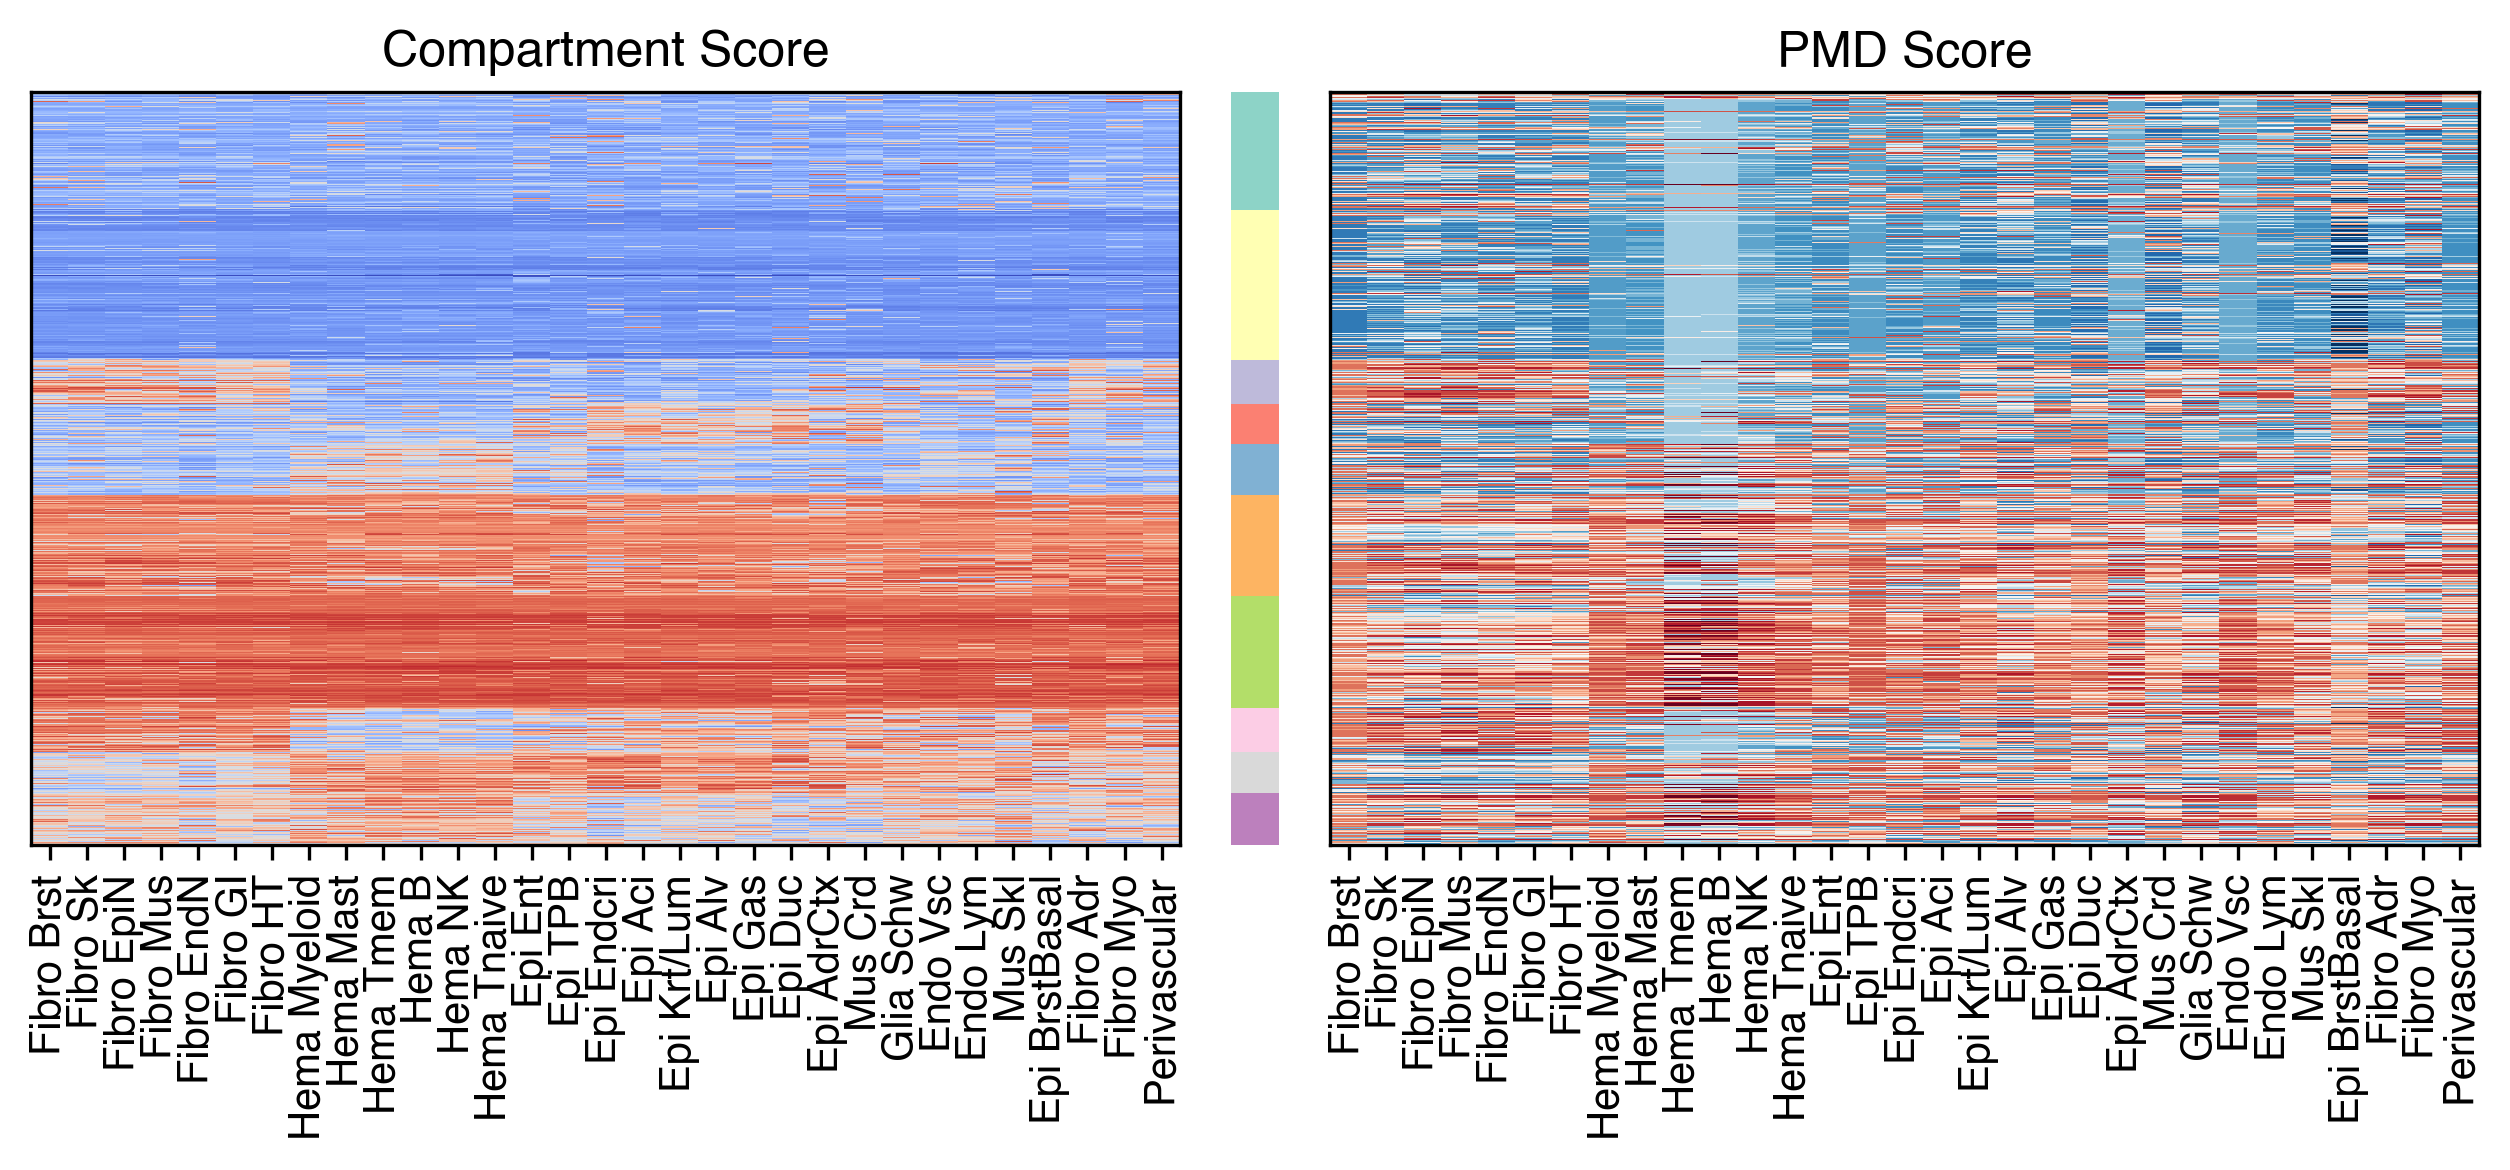

In [14]:
fig, axes = plt.subplots(1, 3, sharey='all', figsize=(8.5,4), dpi=300, 
                         gridspec_kw={'width_ratios': [12, 0.5, 12]}
                        )

ax = axes[0]
ax.imshow(tmp.iloc[:, corder].values, cmap='coolwarm', vmin=-2, vmax=2, 
          interpolation='none', aspect='auto', rasterized=True)
ax.set_title('Loop Strength', fontsize=10)

ax = axes[2]
ax.imshow(zscore(data.iloc[tmp.index, corder], axis=0).values, cmap='RdBu', vmin=-2, vmax=2, 
          interpolation='none', aspect='auto', rasterized=True)
ax.set_title('Compartment Score', fontsize=10)

for i,k in enumerate([0,2]):
    ax = axes[k]
    ax.set_title(['Compartment Score', 'PMD Score'][i])
    ax.set_xticks(np.arange(comp.shape[1]))
    ax.set_xticklabels(comp.columns.map(L1_annot)[corder], rotation=90)
    ax.set_yticks([])

ax = axes[1]
offset = [0] + list(count.cumsum())
ax.axis('off')
for k in range(nc):
    rect = patches.Rectangle((0, offset[k]), 1, offset[k+1]-offset[k], linewidth=0, 
                             edgecolor='none', facecolor=group_palette[k])
    ax.add_patch(rect)

fig.tight_layout()
fig.savefig(f'{outdir}comp_pmd_comporder_kmeans10_nonbrain.pdf', transparent=True)


In [15]:
for ct in comptmp.columns[corder]:
    print(L1_annot[ct], pearsonr(comptmp[ct], datatmp[ct])[0])
    

In [16]:
import pysam

def load_allc(ct, chrom, start, end):
    global indir
    allc_path = f'{indir}merged_allc/L1/CGN/{ct}.CGN-Merge.allc.tsv.gz'
    idx, data_mc, data_cov = [], [], []
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start, end-1)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            pos, mc, cov = int(pos), int(mc), int(cov)
            idx.append(pos-start)
            data_mc.append(mc)
            data_cov.append(cov)
    return  np.array([idx, data_mc, data_cov])

def plot_bw(ct, nbins):
    res = (end-start) // nbins
    idx, tmp_mc, tmp_cov = load_allc(ct, chrom, start, end)
    npos = len(idx)
    mc_tmp, cov_tmp = np.zeros((2, end-start))
    mc_tmp[idx] = tmp_mc
    cov_tmp[idx] = tmp_cov
    mc_tmp = mc_tmp[:res*nbins]
    cov_tmp = cov_tmp[:res*nbins]
    tmp = mc_tmp.reshape((-1, res)).sum(axis=1) / cov_tmp.reshape((-1, res)).sum(axis=1)
    return tmp
    # x = np.arange(len(tmp))
    # # ax.plot(x, tmp, linewidth=0.01)
    # ax.set_xlim([0, nbins])
    # ax.set_ylim([ymin, 1.0])
    # step = nbins//4
    # ax.set_xticks(np.arange(0, nbins+1, step))
    # ax.set_xticklabels([f'{xx//1e6}M' for xx in np.arange(start, end+1, step*res)], fontsize=10)
    # ax.set_yticks([ymin, 1.0])
    # # ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    # ax.fill_between(x, tmp, ymin, where=tmp >= ymin, facecolor=L1_color[ct], interpolate=True)
    # ax.set_title(L1_annot[ct], fontsize=10)
    # return res


In [17]:
ct = 'c1'
chrom = 'chr2'
indir_impute = f'{ENTEX_ROOT}/merged_cool_impute/100K/'


In [18]:
import cooler 
cool_path = f'{indir_impute}L1/{ct}.cool'
cool = cooler.Cooler(cool_path)
Q = cool.matrix(balance=False, sparse=True).fetch(chrom).toarray()
Call = np.zeros(Q.shape)
Q = Q - np.diag(np.diag(Q))
selb = (comp.index.str.split('_').str[0]==chrom)
comptmp = comp.loc[selb, ct]
selb = comp.index.str.split('_').str[1].astype(int)[selb]
Q = Q[selb][:, selb]
decay = np.array([np.mean(np.diag(Q, i)) for i in range(Q.shape[0])])
E = np.zeros(Q.shape)
row, col = np.diag_indices(E.shape[0])
E[row, col] = 1
for i in range(1, E.shape[0]):
    E[row[:-i], col[i:]] = (Q[row[:-i], col[i:]] + 1e-5) / (decay[i] + 1e-5)
E = E + E.T
C = np.corrcoef(np.log2(E + 0.001))
vmin, vmax = np.percentile(C, 5), np.percentile(C, 95)
C[C<vmin] = vmin
C[C>vmax] = vmax
print(vmin, vmax)
Call[np.ix_(selb, selb)] = C.copy()


In [19]:
compall = np.zeros(Call.shape[0])
compall[comptmp.index.str.split('_').str[1].astype(int)] = comptmp.copy()


In [20]:
mcg = pd.read_hdf('mCG_distribution/L1_chrom100k_mCG.hdf', key='data')
mcg = mcg.T.loc[comptmp.index, ct]
mcgall = np.zeros(Call.shape[0])
mcgall[mcg.index.str.split('_').str[1].astype(int)] = mcg.values.copy()


In [21]:
resc = 100000
resm = 10000
start = 0
end = Call.shape[0]*resc
mcg = plot_bw(ct, nbins=Call.shape[0])


In [22]:
colors = {'CG': sns.color_palette('Blues', 1), 'A': sns.color_palette('coolwarm', 2)[1], 'B': sns.color_palette('coolwarm', 2)[0]}

In [23]:
def num2str(num):
    if num>=1e6:
        num_str = f'{int(num//1e6)}M'
    elif num>=1e3:
        num_str = f'{int(num//1e3)}k'
    else:
        num_str = f'{num}'
    return num_str


In [24]:
import anndata
adata = anndata.read_h5ad(f'{pmddir}{ct}_10kb_hist.h5ad')
adata.obs[['chrom','start','end']] = adata.obs.reset_index()['index'].str.split('-', expand=True).values
adata.obs[['start','end']] = adata.obs[['start','end']].astype(int)


In [25]:
adatatmp = adata[(adata.obs['chrom']==chrom)].copy()
mccomp = np.zeros(((end-start)//resm, 100))
mccomp[adatatmp.obs['start']//resm] = adatatmp.X.copy()


In [26]:
label = np.zeros((end-start)//resm) + 4
label[adatatmp.obs['start']//resm] = adatatmp.obs['kmeans4'].values
label = label.astype(int)

In [27]:
cluster_color = sns.color_palette('Set2', 4)
cluster_color = cluster_color + [(1, 1, 1)]
compcolor = np.array([cluster_color[xx] for xx in label])

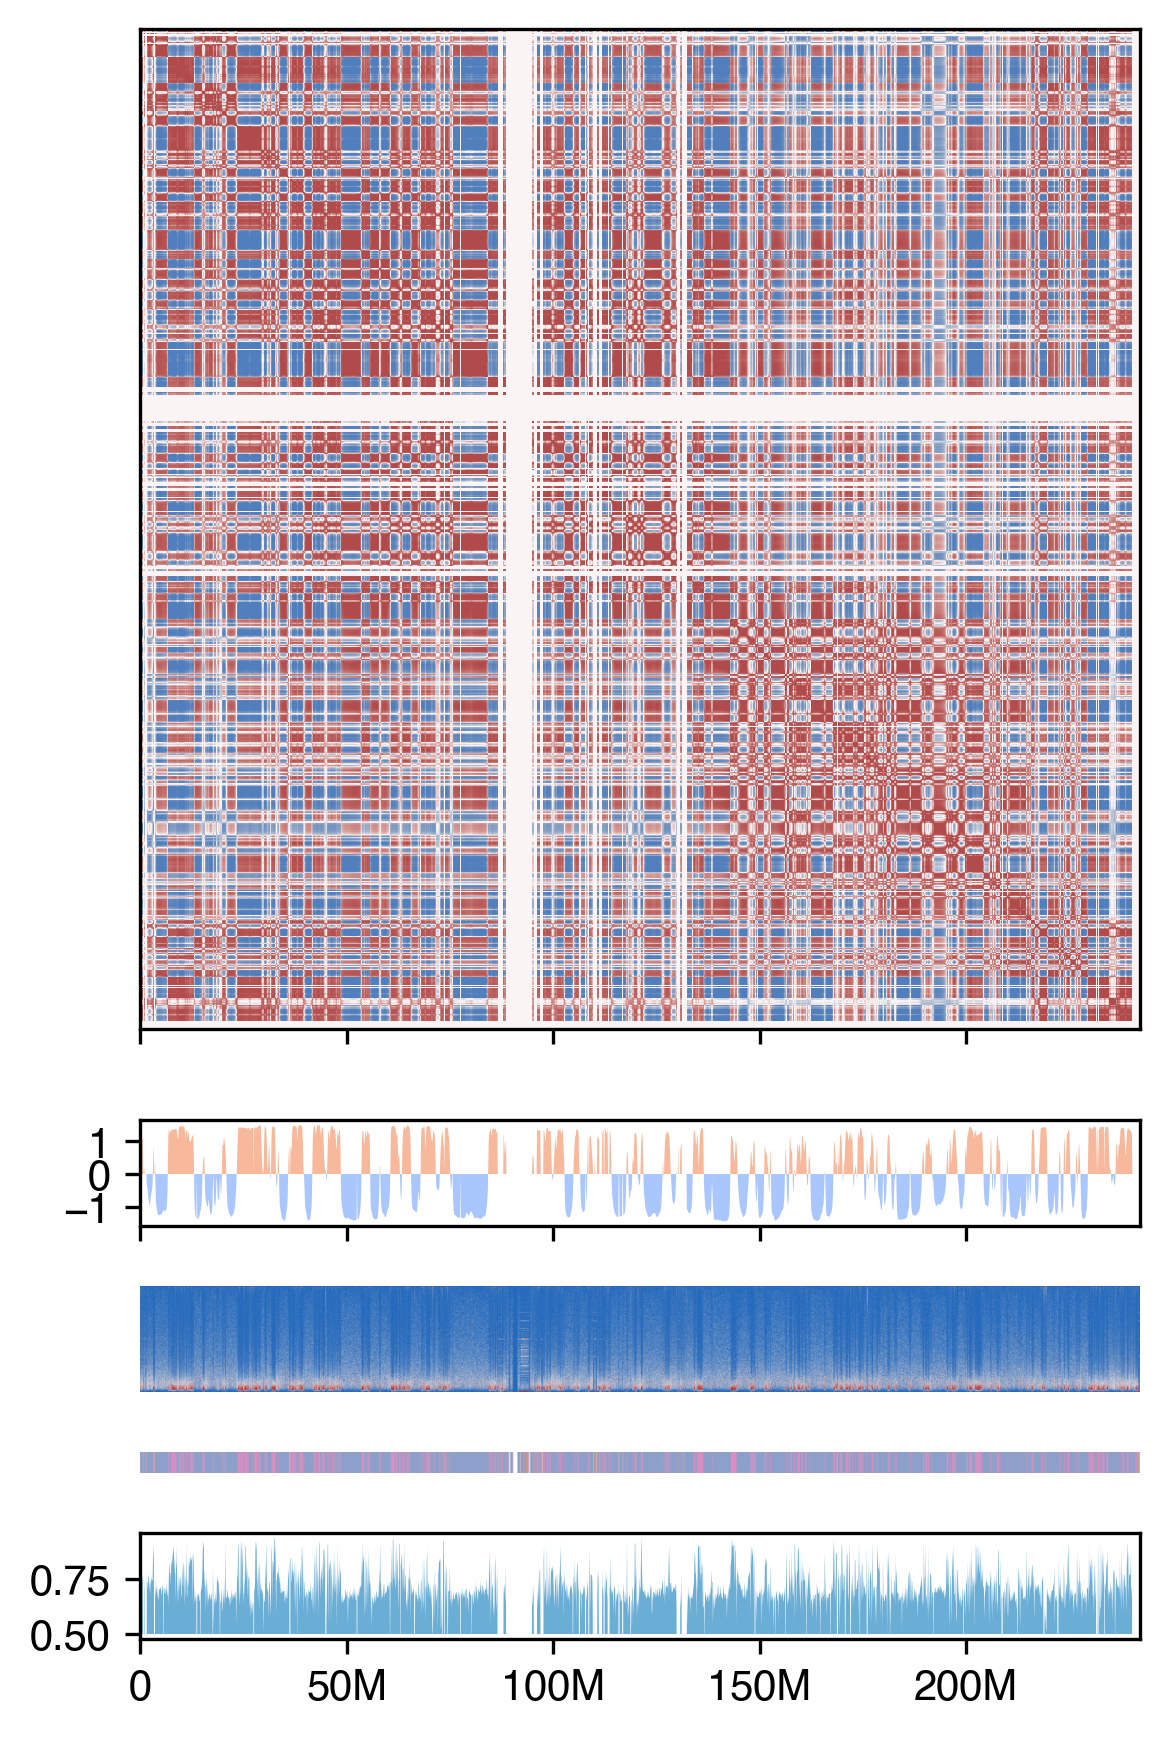

In [28]:
# nbins = 2000
# start = 0
# end = 64000000
ymin = 0.5
xticks_3c = np.arange(0, Call.shape[0]+1, 500)
xticks_mc = np.arange(0, mccomp.shape[0]+1, 5000)

fig, axes = plt.subplots(5, 1, figsize=(4, 6), dpi=300, # sharex='all', 
                         gridspec_kw={'height_ratios': [10,1,1,0.2,1]})
ax = axes[0]
ax.imshow(Call, cmap='vlag', vmin=-1, vmax=1, rasterized=True, interpolation='none')
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_xticks(xticks_3c)
ax.set_xlim([-0.5, Call.shape[0]-0.5])

ax = axes[1]
ax.fill_between(np.arange(compall.shape[0]), compall, 0, where=compall >= 0, facecolor=colors['A'], interpolate=True)
ax.fill_between(np.arange(compall.shape[0]), compall, 0, where=compall <= 0, facecolor=colors['B'], interpolate=True)
ax.set_xlim([-0.5, Call.shape[0]-0.5])
ax.set_xticks(xticks_3c)
ax.set_xticklabels([])

ax = axes[2]
ax.axis('off')
vmax = np.percentile(mccomp,99)
ax.imshow(mccomp.T, cmap='vlag', aspect='auto', vmax=vmax, rasterized=True)
ax.set_xlim([-0.5, mccomp.shape[0]-0.5])

ax = axes[3]
ax.axis('off')
ax.imshow([compcolor], aspect='auto', rasterized=True)

ax = axes[4]
ax.fill_between(np.arange(mcgall.shape[0]), mcgall, ymin, where=mcgall >= ymin, facecolor=colors['CG'], interpolate=True)
ax.set_xlim([-0.5, Call.shape[0]-0.5])
ax.set_xticks(xticks_3c)
ax.set_xticklabels([num2str(xx*res) for xx in xticks_3c])

fig.tight_layout()
fig.savefig(f'{outdir}corr_comp_mCG.pdf', transparent=True)


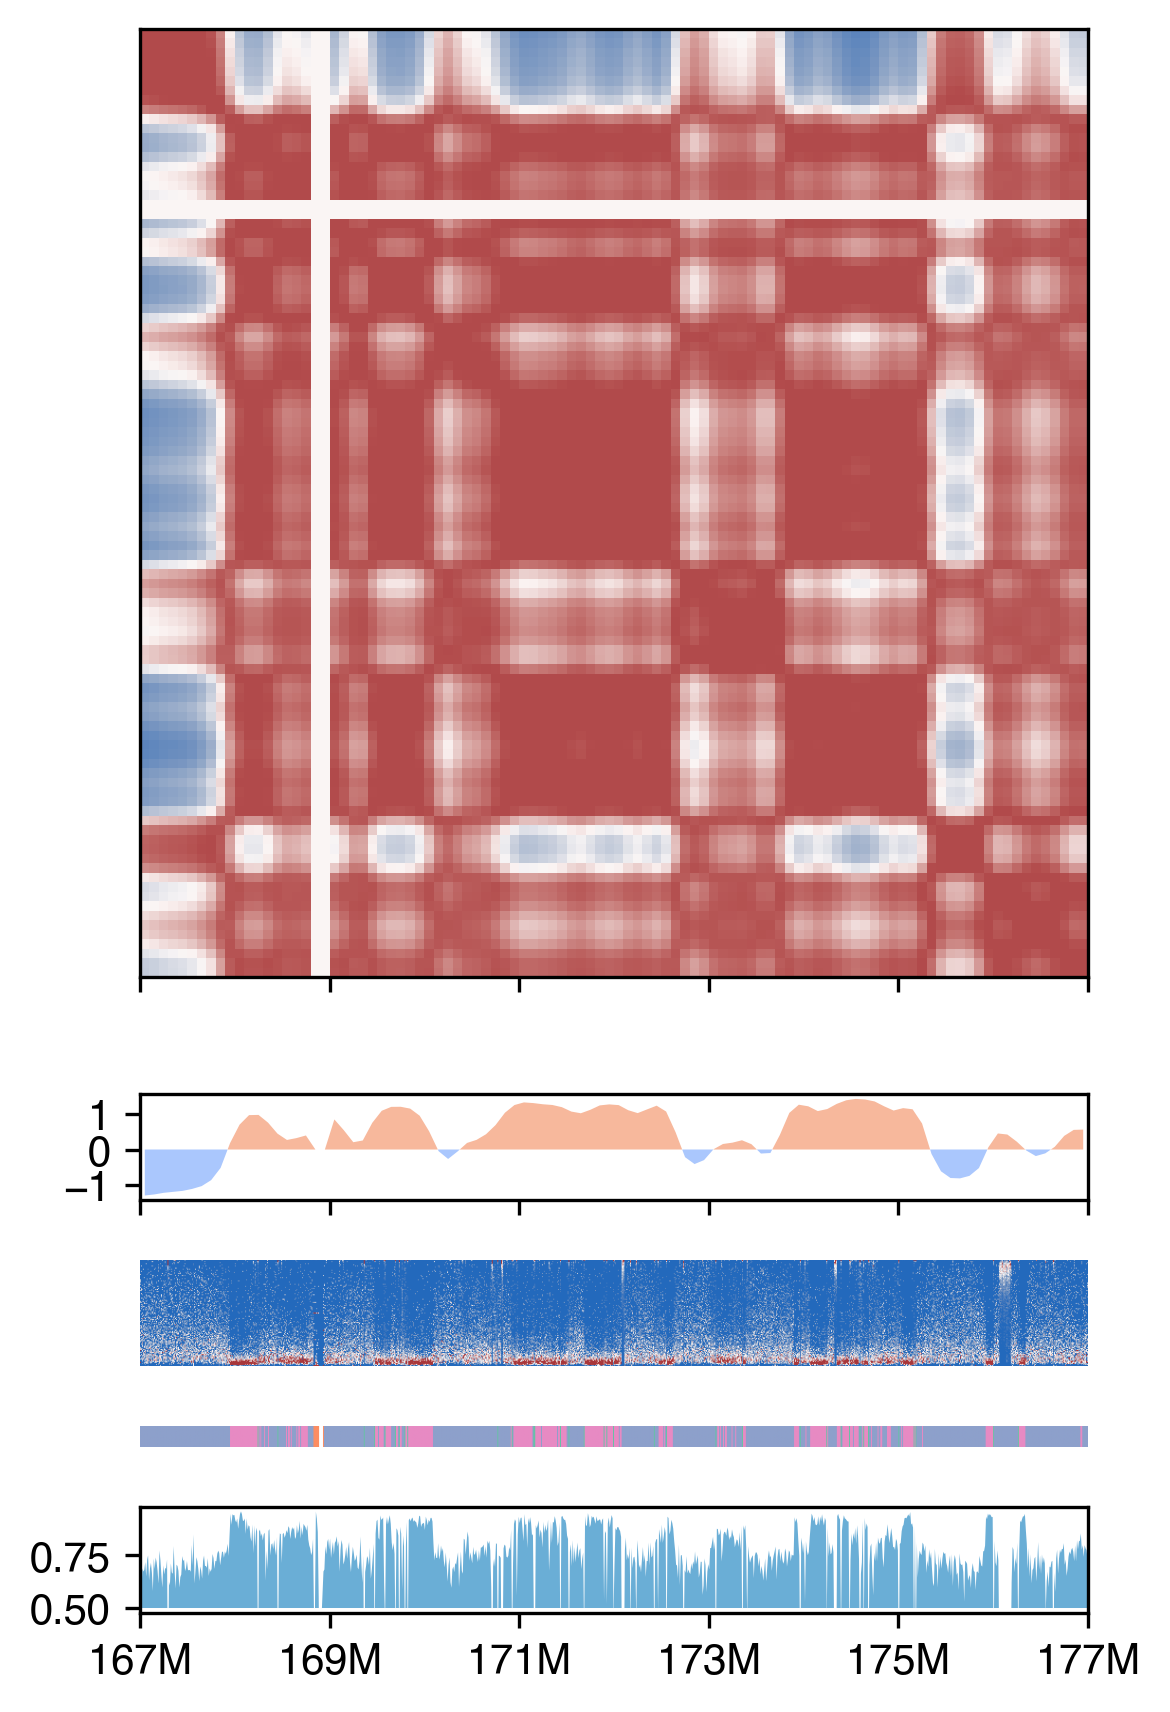

In [29]:
# nbins = 2000
start = 167000000
end = 177000000
ymin = 0.5
xticks_3c = np.arange(0, (end-start)//resc+1, 20)
xticks_mc = np.arange(0, (end-start)//resm+1, 200)

fig, axes = plt.subplots(5, 1, figsize=(4, 6), dpi=300, # sharex='all', 
                         gridspec_kw={'height_ratios': [10,1,1,0.2,1]})
ax = axes[0]
ax.imshow(Call[int(start//resc):int(end//resc)][:, int(start//resc):int(end//resc)], 
          cmap='vlag', vmin=-1, vmax=1, rasterized=True, interpolation='none')
ax.set_yticks([])
ax.set_xticks(xticks_3c-0.5)
ax.set_xticklabels([])
ax.set_xlim([-0.5, (end-start)//resc-0.5])

ax = axes[1]
comptmp = compall[int(start//resc):int(end//resc)]
ax.fill_between(np.arange(comptmp.shape[0]), comptmp, 0, where=comptmp >= 0, facecolor=colors['A'], interpolate=True)
ax.fill_between(np.arange(comptmp.shape[0]), comptmp, 0, where=comptmp <= 0, facecolor=colors['B'], interpolate=True)
ax.set_xticks(xticks_3c-0.5)
ax.set_xticklabels([])
ax.set_xlim([-0.5, (end-start)//resc-0.5])

ax = axes[2]
ax.axis('off')
vmax = np.percentile(mccomp,99)
comptmp = mccomp[int(start//resm):int(end//resm)]
ax.imshow(comptmp.T, cmap='vlag', aspect='auto', vmax=vmax, rasterized=True)
ax.set_xlim([-0.5, (end-start)//resm-0.5])

ax = axes[3]
ax.axis('off')
ax.imshow([compcolor[int(start//resm):int(end//resm)]], aspect='auto', rasterized=True)
ax.set_xlim([-0.5, (end-start)//resm-0.5])

ax = axes[4]
mcgtmp = mcgall[int(start//resc):int(end//resc)]
mcgtmp = plot_bw(ct, nbins=(end-start)//resm)
ax.fill_between(np.arange(mcgtmp.shape[0]), mcgtmp, ymin, where=mcgtmp >= ymin, facecolor=colors['CG'], interpolate=True)
ax.set_xlim([-0.5, (end-start)//resm-0.5])
ax.set_xticks(xticks_mc-0.5)
ax.set_xticklabels([num2str(start+xx*resm) for xx in xticks_mc])

fig.tight_layout()
fig.savefig(f'{outdir}corr_comp_mCG_zoomin.pdf', transparent=True)
